# Circuit Resource Scaling — Visualisation
Generates publication-ready figures from `benchmarks/results/resource_scaling.json`.

In [15]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

In [16]:
with open('results/resource_scaling.json', 'r') as f:
    data = json.load(f)

clone_results = data['clone_sweep_results']
qubit_results = data['qubit_sweep_results']

print(f"Clone sweep rows: {len(clone_results)}")
print(f"Qubit sweep rows: {len(qubit_results)}")

labels_clone = sorted(set(r['label'] for r in clone_results))
labels_qubit = sorted(set(r['label'] for r in qubit_results))
print(f"Clone sweep labels: {labels_clone}")
print(f"Qubit sweep labels: {labels_qubit}")

Clone sweep rows: 21
Qubit sweep rows: 32
Clone sweep labels: ['protocol', 'qarray_set_get', 'qstack_push_pop']
Qubit sweep labels: ['protocol', 'qarray_append_get', 'qarray_set_get', 'qstack_push_pop']


---
## Clone Sweep (m=1, vary n)
### Figure 1: Two-Qubit (CZ) Gate Count vs n — Empirical vs Theoretical

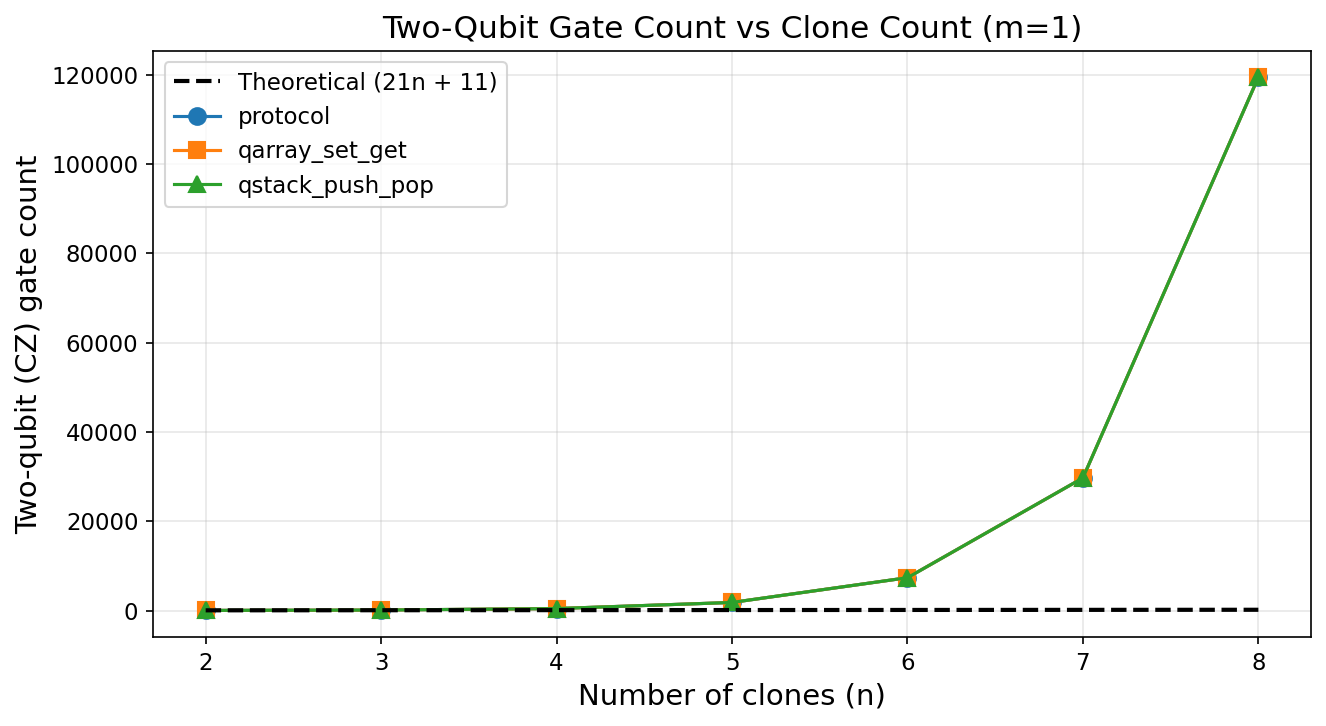

In [17]:
ns = sorted(set(r['n'] for r in clone_results))

fig, ax = plt.subplots(figsize=(9, 5))

# Theoretical line
theory = [r['theoretical_2q_total'] for r in clone_results
          if r['label'] == labels_clone[0]]
ax.plot(ns, theory, 'k--', linewidth=2, label='Theoretical (21n + 11)', zorder=5)

markers = {'protocol': 'o', 'qarray_set_get': 's', 'qstack_push_pop': '^'}
colors = {'protocol': '#1f77b4', 'qarray_set_get': '#ff7f0e', 'qstack_push_pop': '#2ca02c'}

for label in labels_clone:
    cz = [r['cz_gates'] for r in clone_results if r['label'] == label]
    ax.plot(ns, cz, f"{markers.get(label, 'o')}-",
            color=colors.get(label, 'grey'),
            label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Two-qubit (CZ) gate count')
ax.set_title('Two-Qubit Gate Count vs Clone Count (m=1)')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_cz_vs_n.png')
plt.show()

### Figure 2: Overhead Ratio (Empirical / Theoretical) vs n

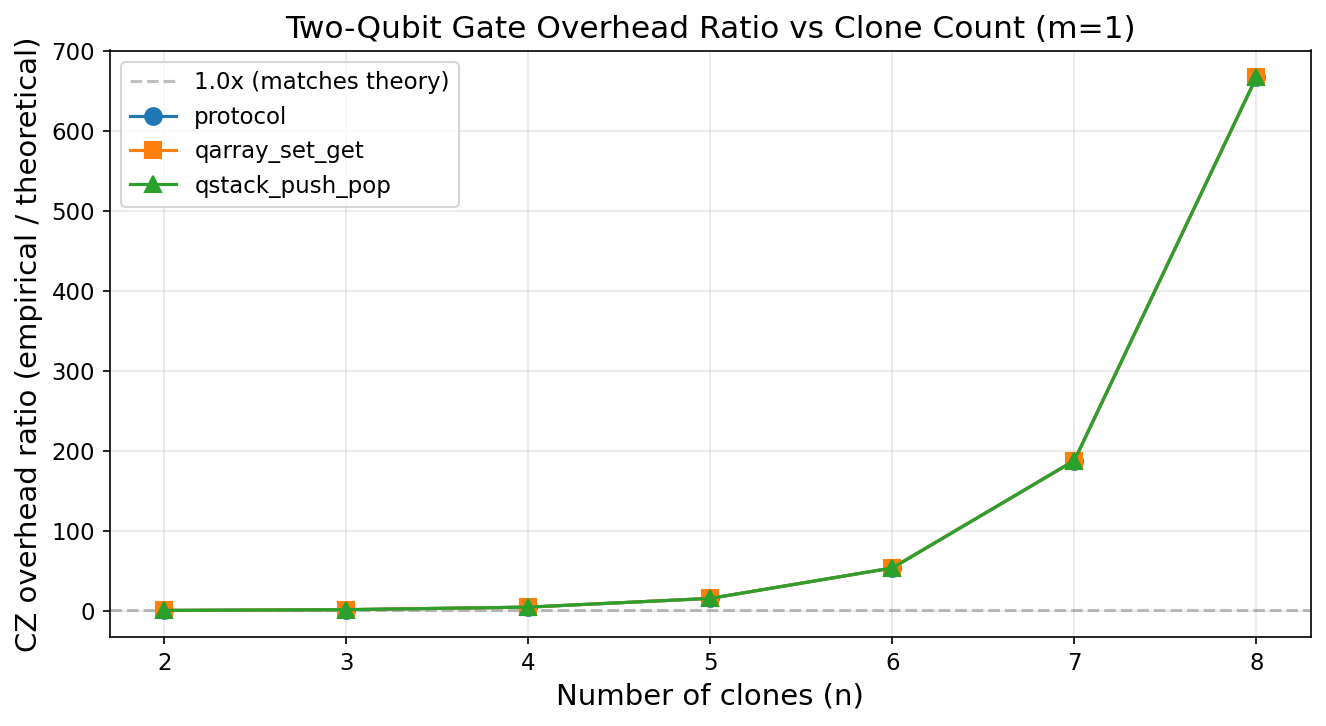

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5, label='1.0x (matches theory)')

for label in labels_clone:
    ratios = [r['2q_overhead_ratio'] for r in clone_results if r['label'] == label]
    ax.plot(ns, ratios, f"{markers.get(label, 'o')}-",
            color=colors.get(label, 'grey'),
            label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('CZ overhead ratio (empirical / theoretical)')
ax.set_title('Two-Qubit Gate Overhead Ratio vs Clone Count (m=1)')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_overhead_ratio.png')
plt.show()

### Figure 3: Circuit Depth vs n

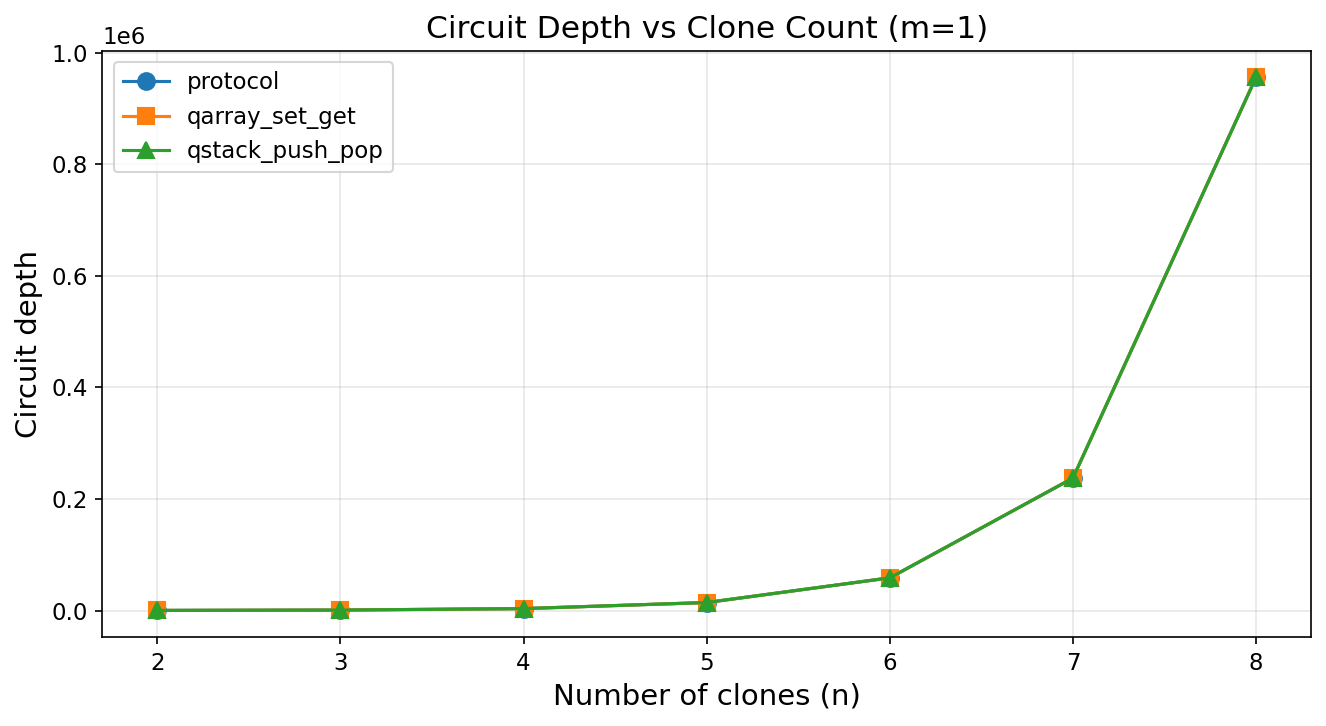

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

for label in labels_clone:
    depths = [r['circuit_depth'] for r in clone_results if r['label'] == label]
    ax.plot(ns, depths, f"{markers.get(label, 'o')}-",
            color=colors.get(label, 'grey'),
            label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Circuit depth')
ax.set_title('Circuit Depth vs Clone Count (m=1)')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_depth_vs_n.png')
plt.show()

### Figure 4: Total Qubits vs n (with theoretical verification)

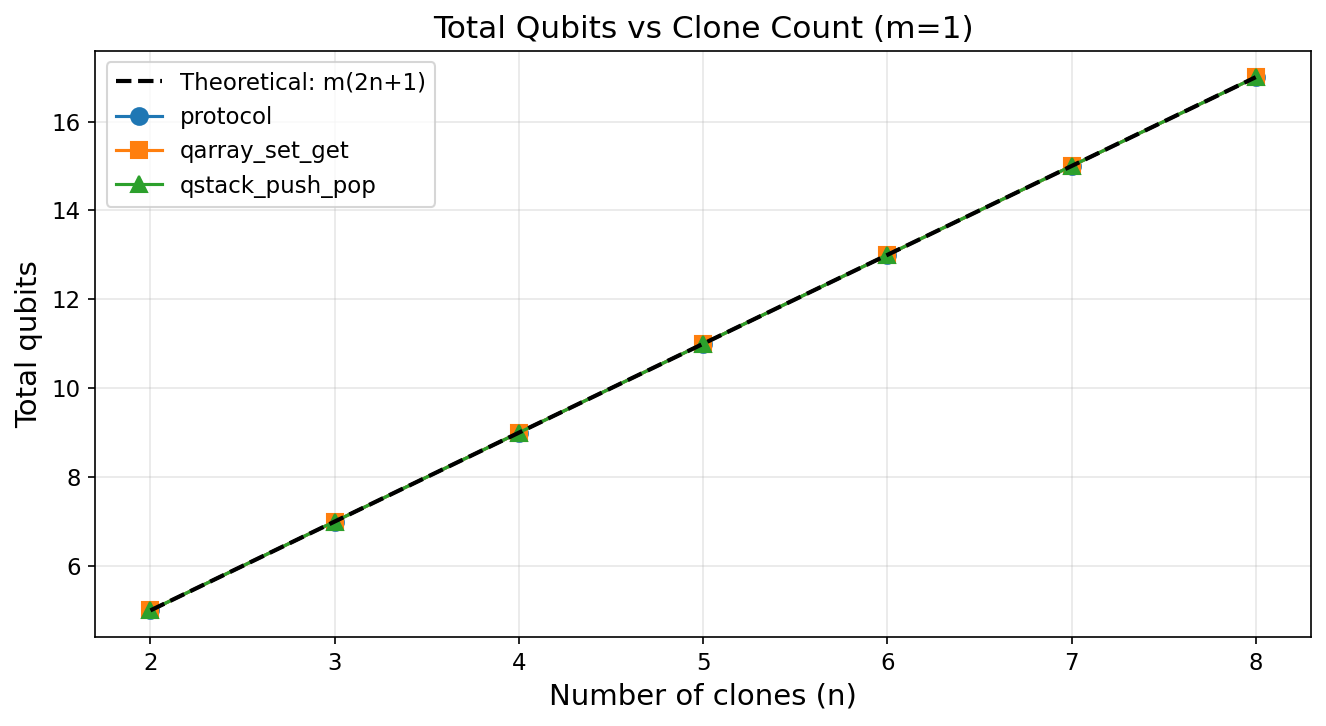

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))

# Theoretical
theory_q = [r['theoretical_qubits'] for r in clone_results
            if r['label'] == labels_clone[0]]
ax.plot(ns, theory_q, 'k--', linewidth=2, label='Theoretical: m(2n+1)', zorder=5)

for label in labels_clone:
    qubits = [r['total_qubits'] for r in clone_results if r['label'] == label]
    ax.plot(ns, qubits, f"{markers.get(label, 'o')}-",
            color=colors.get(label, 'grey'),
            label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Total qubits')
ax.set_title('Total Qubits vs Clone Count (m=1)')
ax.set_xticks(ns)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_qubits_vs_n.png')
plt.show()

### Figure 5: Encryption vs Decryption Build Time (m=1)

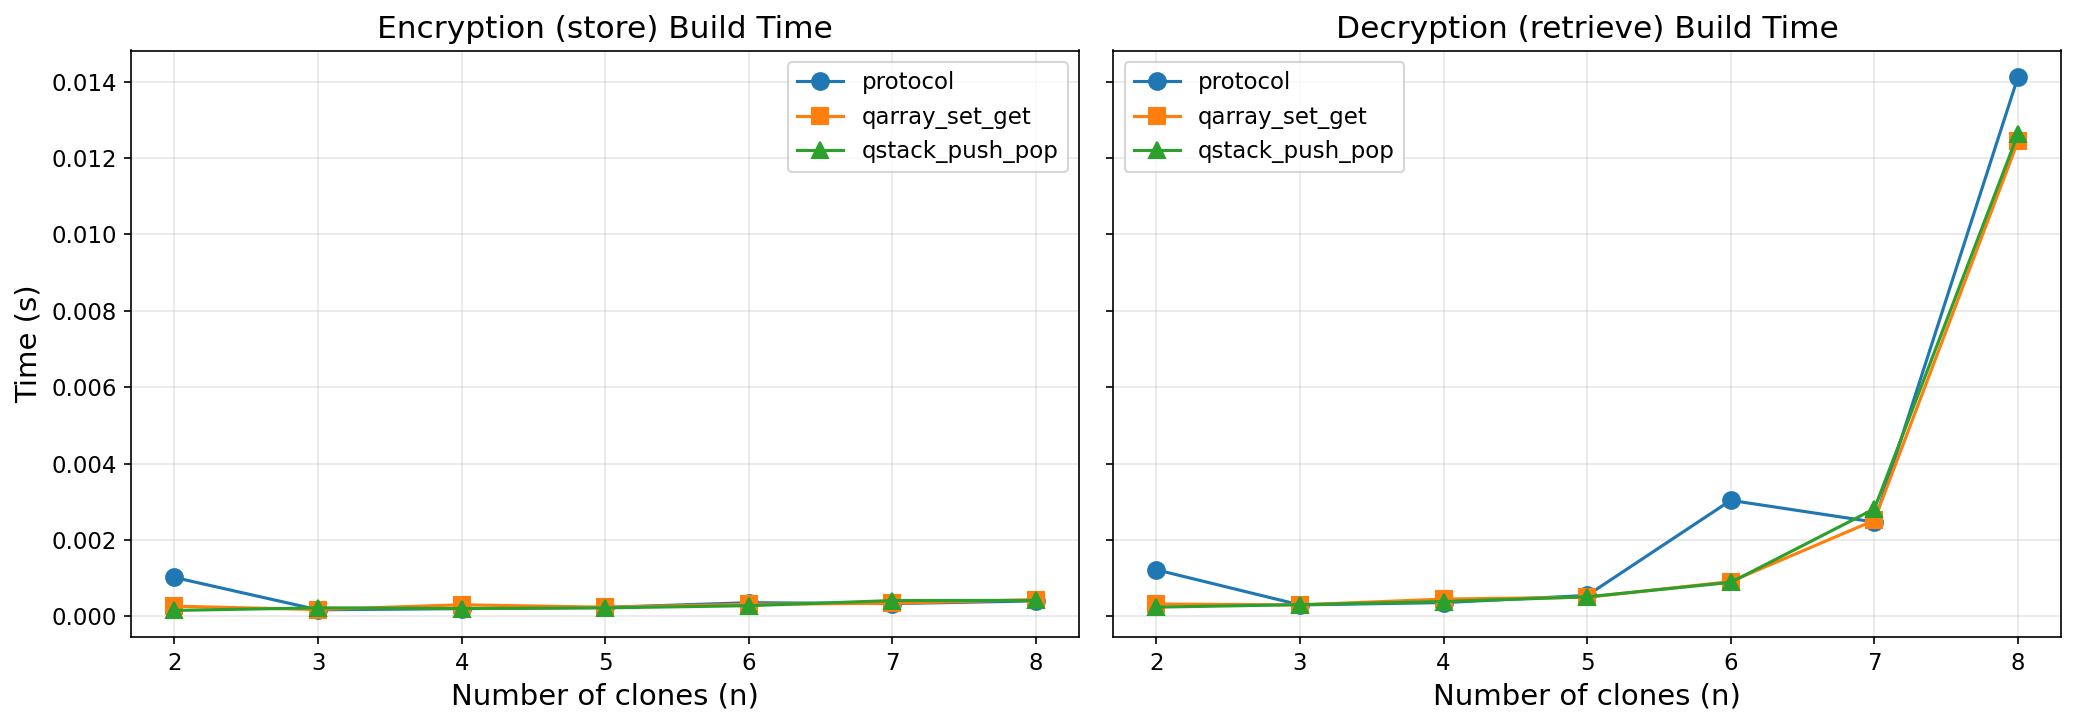

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for label in labels_clone:
    enc = [r['encrypt_time_s'] for r in clone_results if r['label'] == label]
    dec = [r['decrypt_time_s'] for r in clone_results if r['label'] == label]
    
    axes[0].plot(ns, enc, f"{markers.get(label, 'o')}-",
                color=colors.get(label, 'grey'),
                label=label, markersize=8)
    axes[1].plot(ns, dec, f"{markers.get(label, 'o')}-",
                color=colors.get(label, 'grey'),
                label=label, markersize=8)

axes[0].set_xlabel('Number of clones (n)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Encryption (store) Build Time')
axes[0].set_xticks(ns)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Number of clones (n)')
axes[1].set_title('Decryption (retrieve) Build Time')
axes[1].set_xticks(ns)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_enc_dec_time.png')
plt.show()

### Figure 6: Simulation Time vs n (m=1)

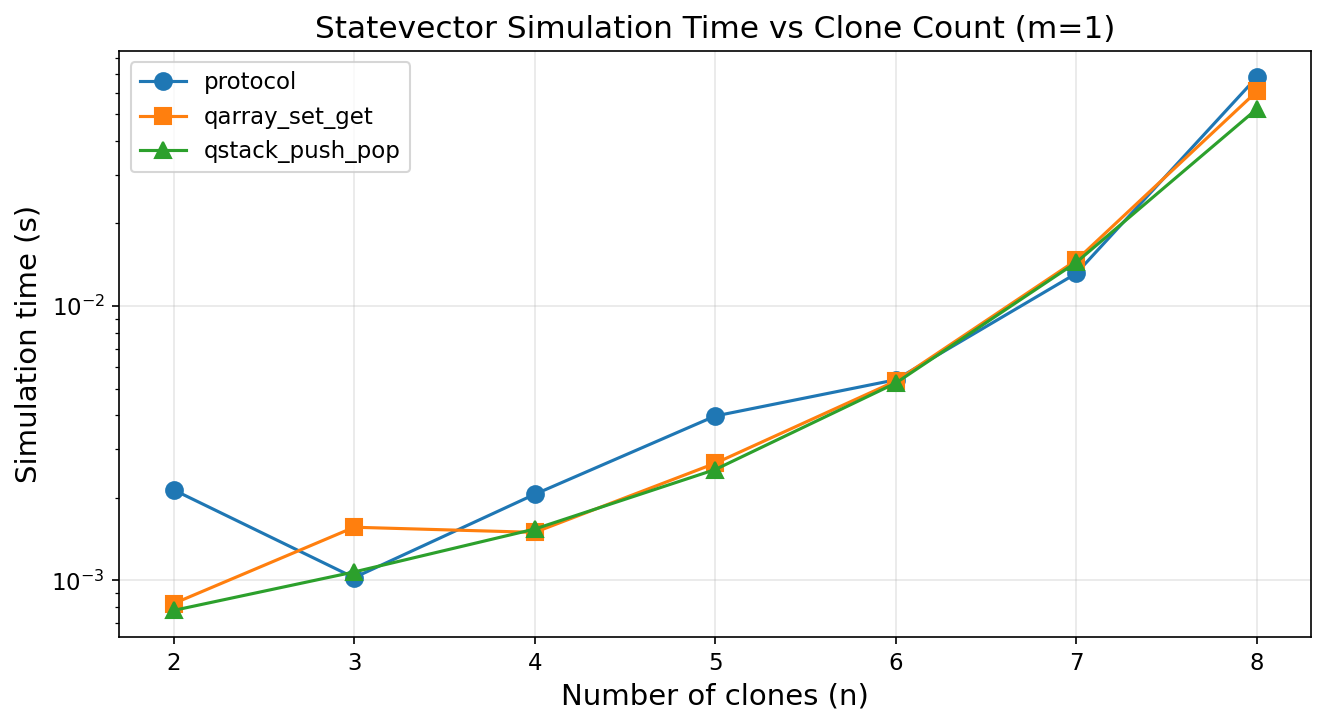

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

for label in labels_clone:
    sim_times = [r['sim_time_s'] for r in clone_results if r['label'] == label]
    # Filter out None values
    valid = [(n, t) for n, t in zip(ns, sim_times) if t is not None]
    if valid:
        vn, vt = zip(*valid)
        ax.plot(vn, vt, f"{markers.get(label, 'o')}-",
                color=colors.get(label, 'grey'),
                label=label, markersize=8)

ax.set_xlabel('Number of clones (n)')
ax.set_ylabel('Simulation time (s)')
ax.set_title('Statevector Simulation Time vs Clone Count (m=1)')
ax.set_xticks(ns)
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/clone_sweep_sim_time.png')
plt.show()

---
## Qubit Sweep (fixed n, vary m)
### Figure 7: CZ Gate Count vs m (per fixed n)

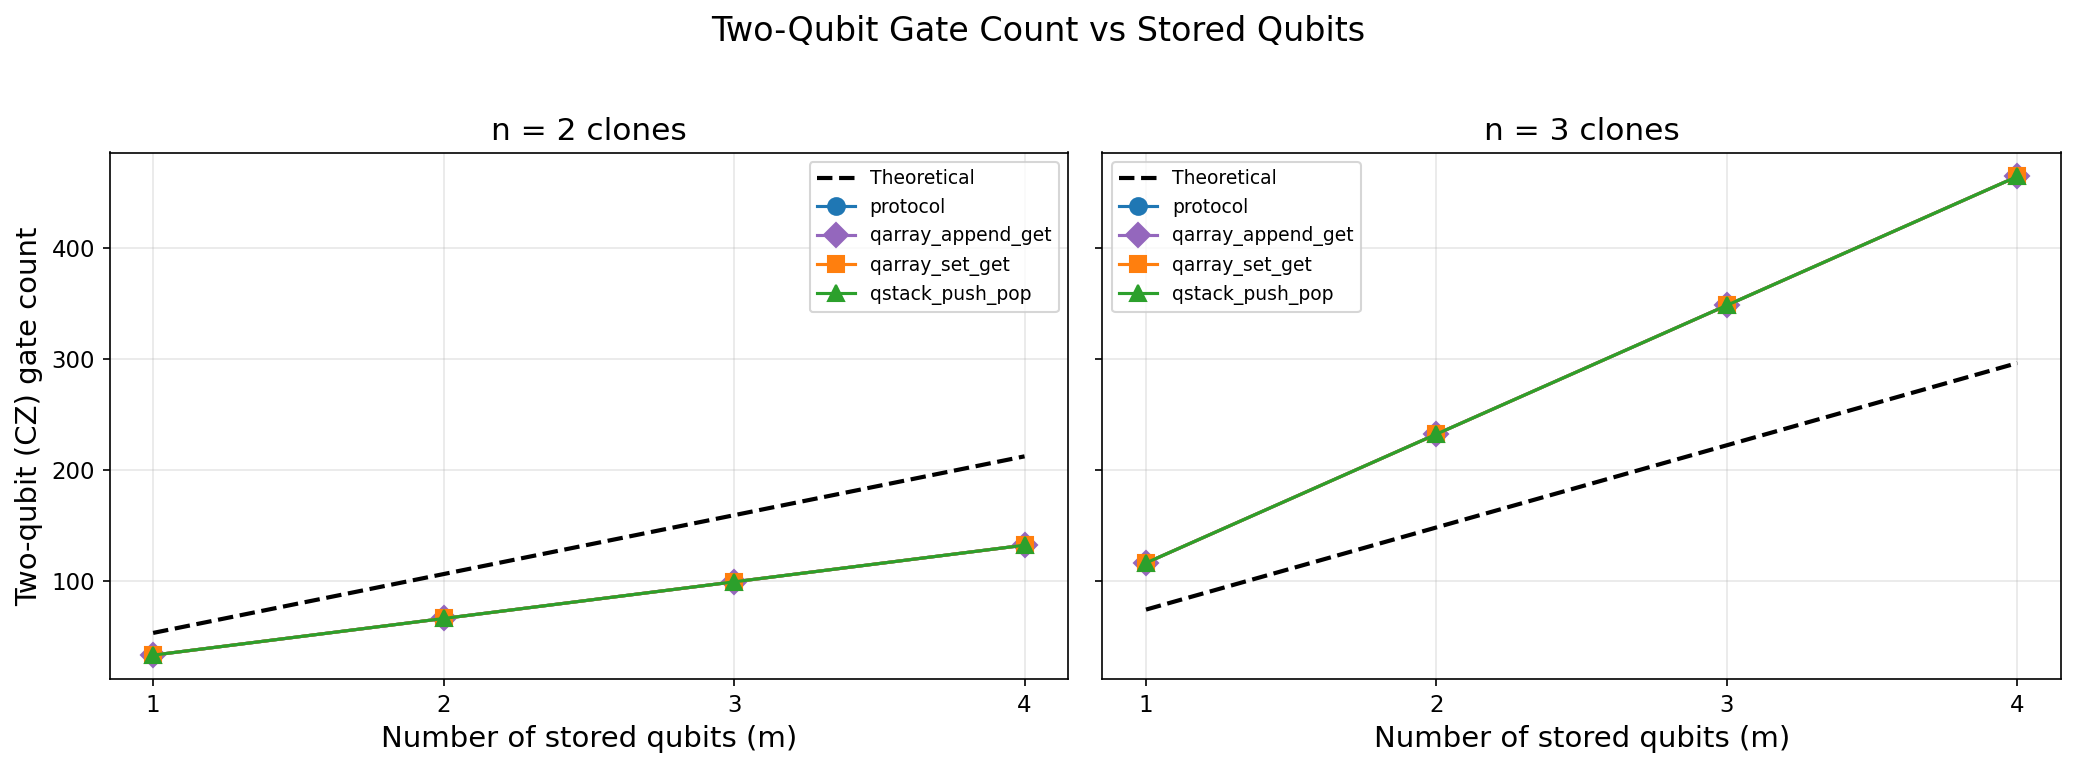

In [23]:
n_values = sorted(set(r['n'] for r in qubit_results))
markers_q = {'protocol': 'o', 'qarray_set_get': 's',
             'qarray_append_get': 'D', 'qstack_push_pop': '^'}
colors_q = {'protocol': '#1f77b4', 'qarray_set_get': '#ff7f0e',
            'qarray_append_get': '#9467bd', 'qstack_push_pop': '#2ca02c'}

fig, axes = plt.subplots(1, len(n_values), figsize=(7*len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for idx, n in enumerate(n_values):
    ax = axes[idx]
    sub = [r for r in qubit_results if r['n'] == n]
    ms = sorted(set(r['m'] for r in sub))
    
    # Theoretical
    theory = [r['theoretical_2q_total'] for r in sub
              if r['label'] == labels_qubit[0]]
    ax.plot(ms, theory, 'k--', linewidth=2, label='Theoretical', zorder=5)
    
    for label in labels_qubit:
        cz = [r['cz_gates'] for r in sub if r['label'] == label]
        ax.plot(ms, cz, f"{markers_q.get(label, 'o')}-",
                color=colors_q.get(label, 'grey'),
                label=label, markersize=8)
    
    ax.set_xlabel('Number of stored qubits (m)')
    if idx == 0:
        ax.set_ylabel('Two-qubit (CZ) gate count')
    ax.set_title(f'n = {n} clones')
    ax.set_xticks(ms)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Two-Qubit Gate Count vs Stored Qubits', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/qubit_sweep_cz_vs_m.png')
plt.show()

### Figure 8: Circuit Depth vs m (per fixed n)

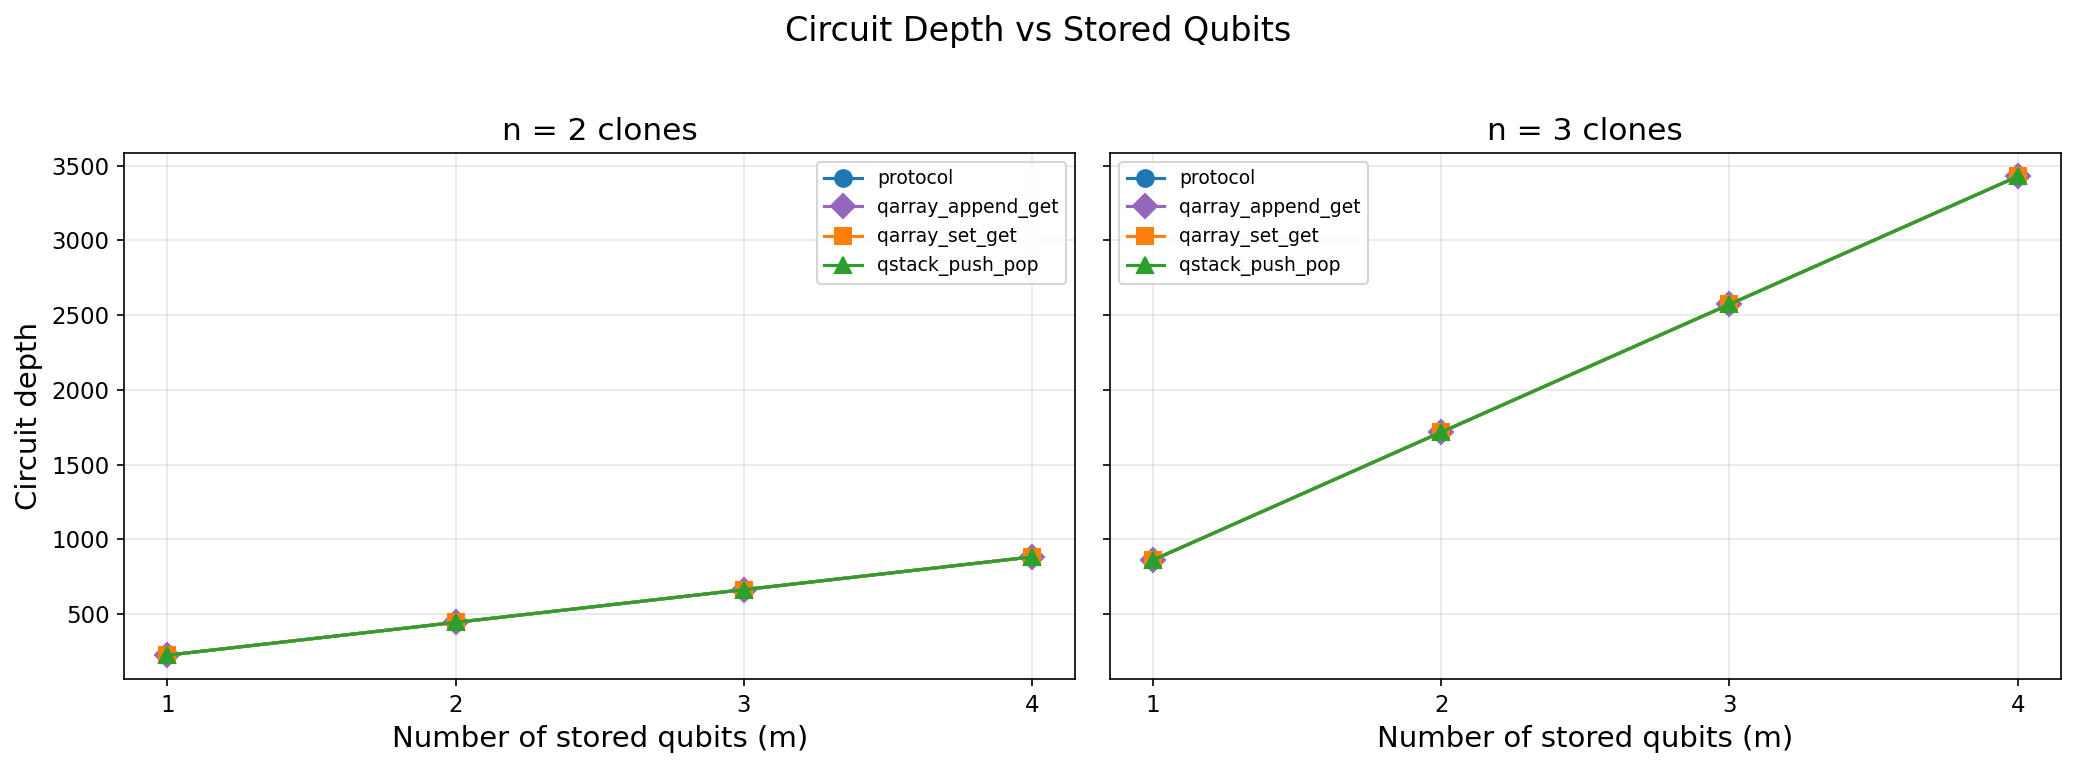

In [24]:
fig, axes = plt.subplots(1, len(n_values), figsize=(7*len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for idx, n in enumerate(n_values):
    ax = axes[idx]
    sub = [r for r in qubit_results if r['n'] == n]
    ms = sorted(set(r['m'] for r in sub))
    
    for label in labels_qubit:
        depths = [r['circuit_depth'] for r in sub if r['label'] == label]
        ax.plot(ms, depths, f"{markers_q.get(label, 'o')}-",
                color=colors_q.get(label, 'grey'),
                label=label, markersize=8)
    
    ax.set_xlabel('Number of stored qubits (m)')
    if idx == 0:
        ax.set_ylabel('Circuit depth')
    ax.set_title(f'n = {n} clones')
    ax.set_xticks(ms)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Circuit Depth vs Stored Qubits', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/qubit_sweep_depth_vs_m.png')
plt.show()

### Figure 9: Encryption vs Decryption Build Time (qubit sweep)

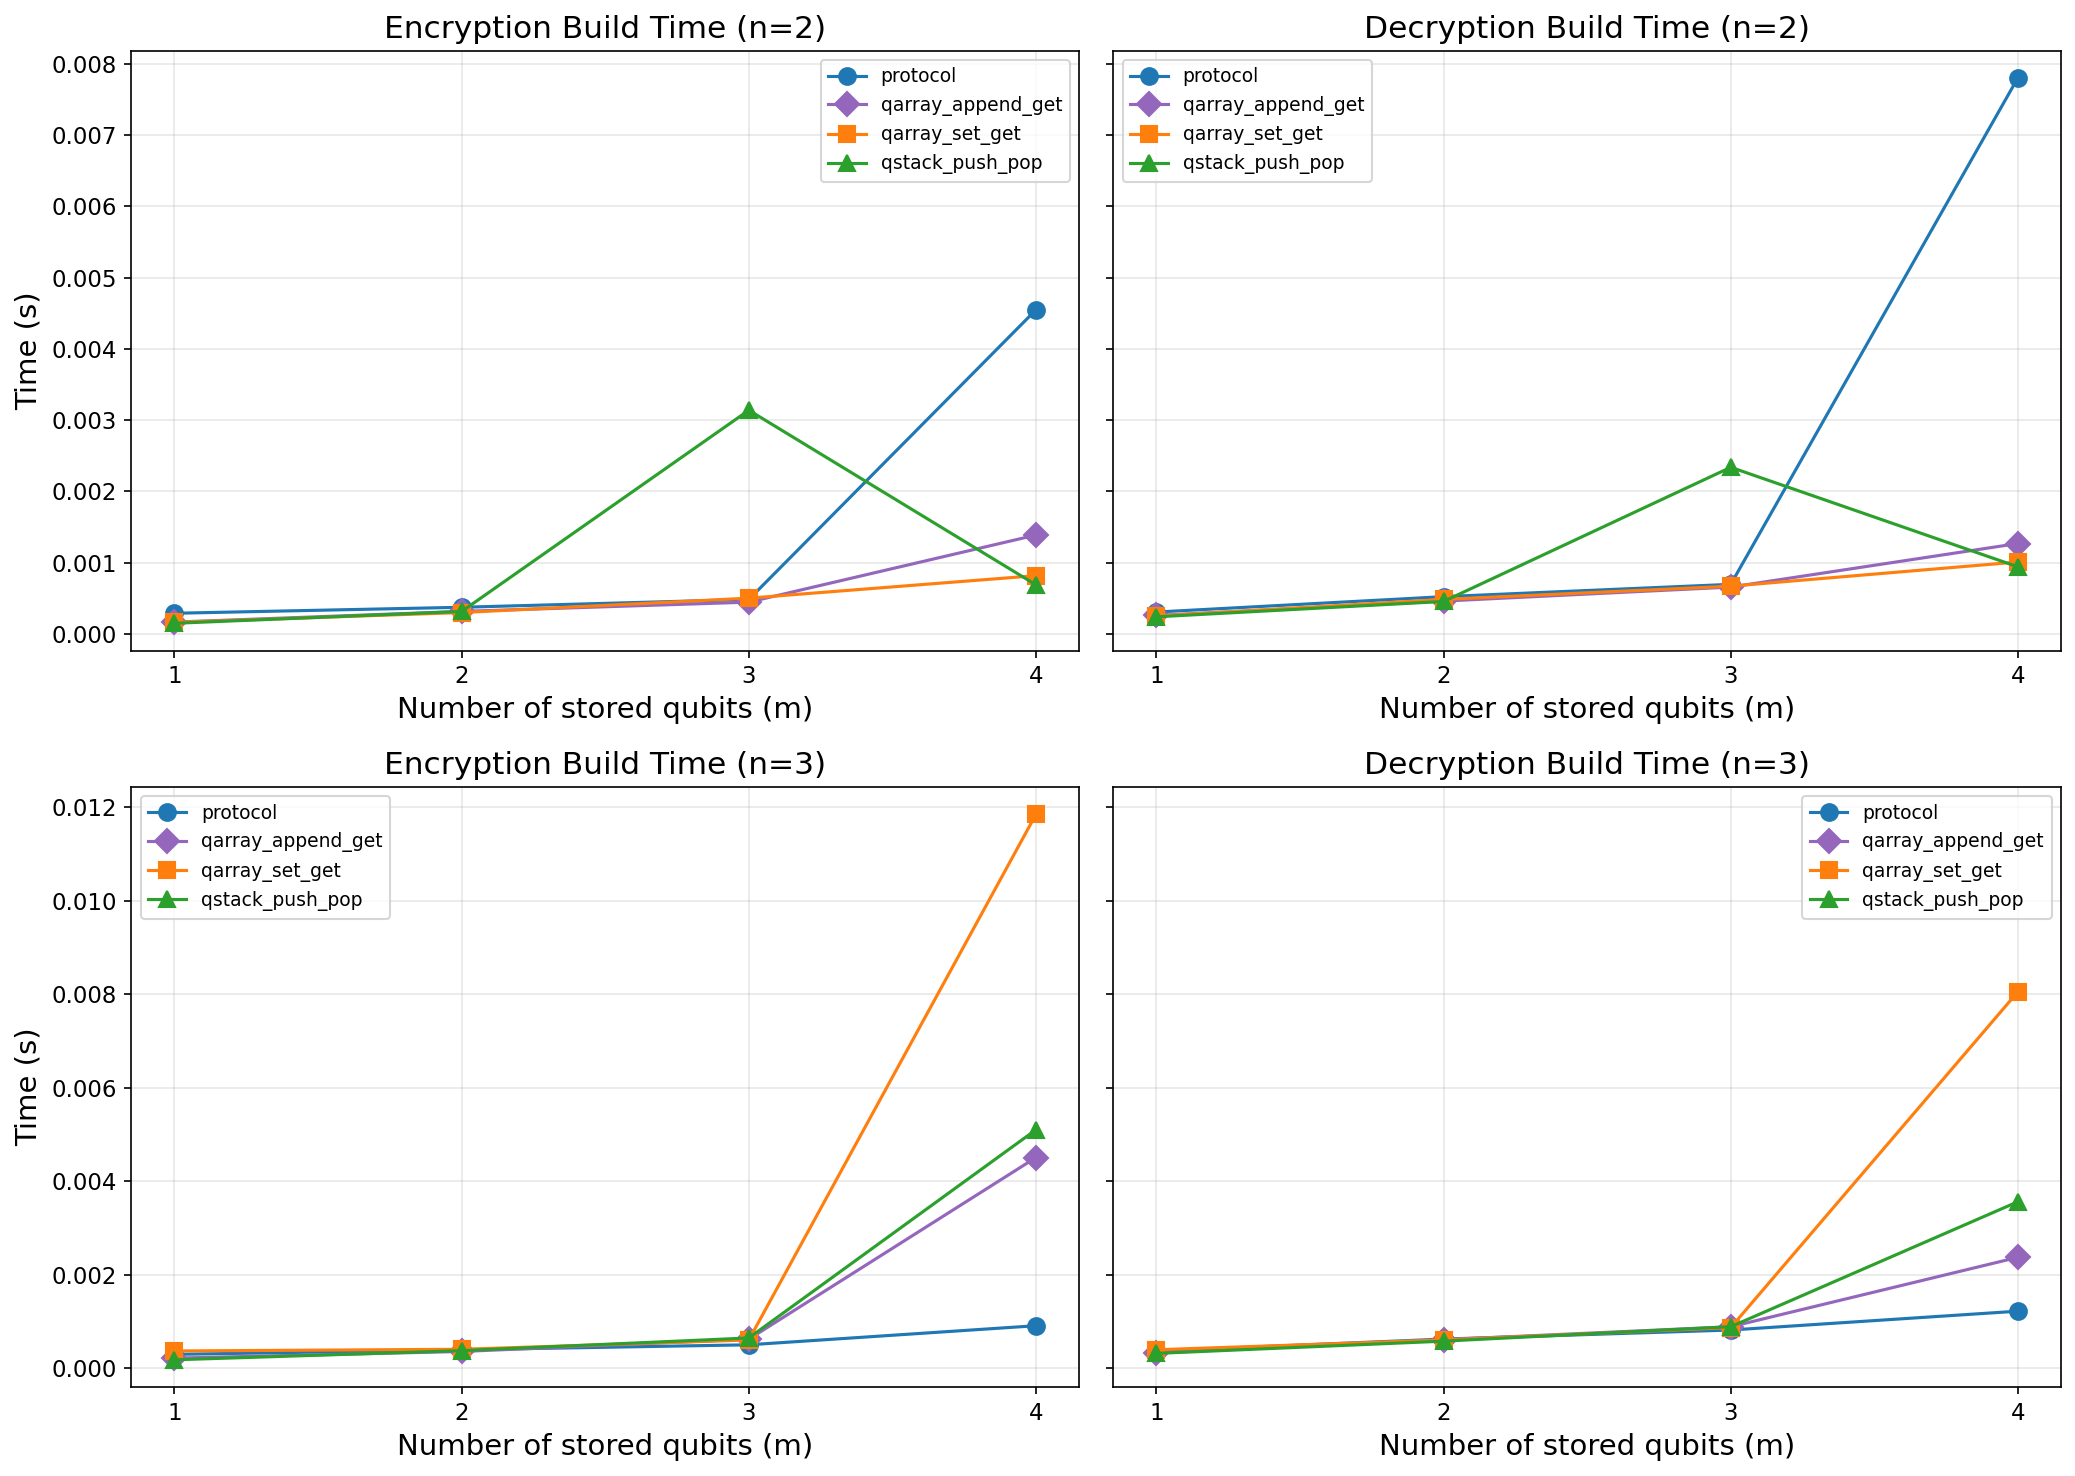

In [25]:
fig, axes = plt.subplots(len(n_values), 2, figsize=(14, 5*len(n_values)), sharey='row')
if len(n_values) == 1:
    axes = [axes]

for idx, n in enumerate(n_values):
    sub = [r for r in qubit_results if r['n'] == n]
    ms = sorted(set(r['m'] for r in sub))
    
    for label in labels_qubit:
        enc = [r['encrypt_time_s'] for r in sub if r['label'] == label]
        dec = [r['decrypt_time_s'] for r in sub if r['label'] == label]
        
        axes[idx][0].plot(ms, enc, f"{markers_q.get(label, 'o')}-",
                         color=colors_q.get(label, 'grey'),
                         label=label, markersize=8)
        axes[idx][1].plot(ms, dec, f"{markers_q.get(label, 'o')}-",
                         color=colors_q.get(label, 'grey'),
                         label=label, markersize=8)
    
    axes[idx][0].set_xlabel('Number of stored qubits (m)')
    axes[idx][0].set_ylabel('Time (s)')
    axes[idx][0].set_title(f'Encryption Build Time (n={n})')
    axes[idx][0].set_xticks(ms)
    axes[idx][0].legend(fontsize=9)
    axes[idx][0].grid(True, alpha=0.3)
    
    axes[idx][1].set_xlabel('Number of stored qubits (m)')
    axes[idx][1].set_title(f'Decryption Build Time (n={n})')
    axes[idx][1].set_xticks(ms)
    axes[idx][1].legend(fontsize=9)
    axes[idx][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/qubit_sweep_enc_dec_time.png')
plt.show()

### Figure 10: Total Qubits vs m (with theoretical verification)

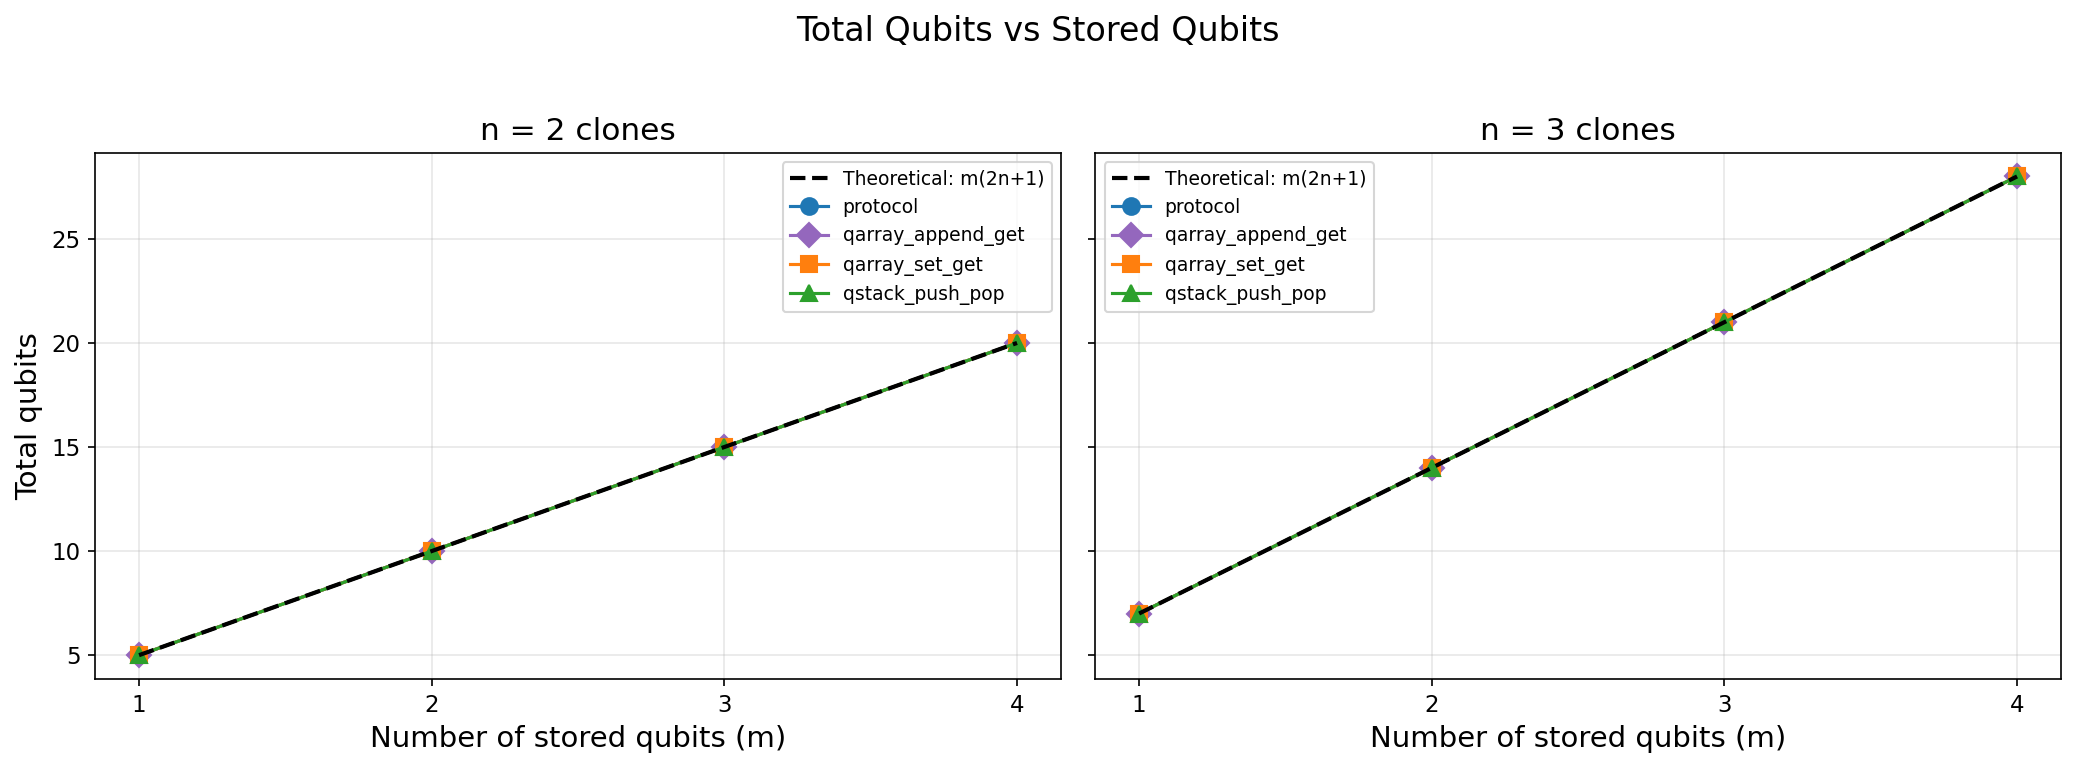

In [26]:
fig, axes = plt.subplots(1, len(n_values), figsize=(7*len(n_values), 5), sharey=True)
if len(n_values) == 1:
    axes = [axes]

for idx, n in enumerate(n_values):
    ax = axes[idx]
    sub = [r for r in qubit_results if r['n'] == n]
    ms = sorted(set(r['m'] for r in sub))
    
    theory_q = [r['theoretical_qubits'] for r in sub
                if r['label'] == labels_qubit[0]]
    ax.plot(ms, theory_q, 'k--', linewidth=2, label='Theoretical: m(2n+1)', zorder=5)
    
    for label in labels_qubit:
        qubits = [r['total_qubits'] for r in sub if r['label'] == label]
        ax.plot(ms, qubits, f"{markers_q.get(label, 'o')}-",
                color=colors_q.get(label, 'grey'),
                label=label, markersize=8)
    
    ax.set_xlabel('Number of stored qubits (m)')
    if idx == 0:
        ax.set_ylabel('Total qubits')
    ax.set_title(f'n = {n} clones')
    ax.set_xticks(ms)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Total Qubits vs Stored Qubits', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('figures/qubit_sweep_qubits_vs_m.png')
plt.show()

---
## Summary Tables

In [27]:
print('='*100)
print('CLONE SWEEP SUMMARY (m=1)')
print('='*100)
print(f"{'n':>3}  {'label':<22}  {'qubits':>6}  {'q_ok':>4}  {'CZ':>6}  "
      f"{'theory':>6}  {'ratio':>7}  {'depth':>6}  "
      f"{'enc_s':>8}  {'dec_s':>8}  {'sim_s':>8}")
print('-'*100)

for r in sorted(clone_results, key=lambda x: (x['n'], x['label'])):
    q_ok = '✓' if r['qubits_match_theory'] else '✗'
    ratio = f"{r['2q_overhead_ratio']:.2f}x" if r['2q_overhead_ratio'] else '—'
    sim = f"{r['sim_time_s']:.4f}" if r.get('sim_time_s') is not None else '—'
    print(f"{r['n']:>3}  {r['label']:<22}  {r['total_qubits']:>6}  {q_ok:>4}  "
          f"{r['cz_gates']:>6}  {r['theoretical_2q_total']:>6}  "
          f"{ratio:>7}  {r['circuit_depth']:>6}  "
          f"{r['encrypt_time_s']:>8.4f}  {r['decrypt_time_s']:>8.4f}  "
          f"{sim:>8}")

CLONE SWEEP SUMMARY (m=1)
  n  label                   qubits  q_ok      CZ  theory    ratio   depth     enc_s     dec_s     sim_s
----------------------------------------------------------------------------------------------------
  2  protocol                     5     ✓      33      53    0.62x     226    0.0010    0.0012    0.0021
  2  qarray_set_get               5     ✓      33      53    0.62x     226    0.0003    0.0003    0.0008
  2  qstack_push_pop              5     ✓      33      53    0.62x     226    0.0002    0.0002    0.0008
  3  protocol                     7     ✓     116      74    1.57x     862    0.0002    0.0003    0.0010
  3  qarray_set_get               7     ✓     116      74    1.57x     862    0.0002    0.0003    0.0016
  3  qstack_push_pop              7     ✓     116      74    1.57x     862    0.0002    0.0003    0.0011
  4  protocol                     9     ✓     450      95    4.74x    3497    0.0002    0.0004    0.0021
  4  qarray_set_get              

In [28]:
for n in sorted(set(r['n'] for r in qubit_results)):
    sub = [r for r in qubit_results if r['n'] == n]
    print()
    print('='*100)
    print(f'QUBIT SWEEP SUMMARY (n={n})')
    print('='*100)
    print(f"{'m':>3}  {'label':<22}  {'qubits':>6}  {'q_ok':>4}  {'CZ':>6}  "
          f"{'theory':>6}  {'ratio':>7}  {'depth':>6}  "
          f"{'enc_s':>8}  {'dec_s':>8}  {'sim_s':>8}")
    print('-'*100)
    
    for r in sorted(sub, key=lambda x: (x['m'], x['label'])):
        q_ok = '✓' if r['qubits_match_theory'] else '✗'
        ratio = f"{r['2q_overhead_ratio']:.2f}x" if r['2q_overhead_ratio'] else '—'
        sim = f"{r['sim_time_s']:.4f}" if r.get('sim_time_s') is not None else '—'
        print(f"{r['m']:>3}  {r['label']:<22}  {r['total_qubits']:>6}  {q_ok:>4}  "
              f"{r['cz_gates']:>6}  {r['theoretical_2q_total']:>6}  "
              f"{ratio:>7}  {r['circuit_depth']:>6}  "
              f"{r['encrypt_time_s']:>8.4f}  {r['decrypt_time_s']:>8.4f}  "
              f"{sim:>8}")


QUBIT SWEEP SUMMARY (n=2)
  m  label                   qubits  q_ok      CZ  theory    ratio   depth     enc_s     dec_s     sim_s
----------------------------------------------------------------------------------------------------
  1  protocol                     5     ✓      33      53    0.62x     226    0.0003    0.0003    0.0008
  1  qarray_append_get            5     ✓      33      53    0.62x     226    0.0002    0.0003    0.0007
  1  qarray_set_get               5     ✓      33      53    0.62x     226    0.0002    0.0002    0.0008
  1  qstack_push_pop              5     ✓      33      53    0.62x     226    0.0001    0.0002    0.0011
  2  protocol                    10     ✓      66     106    0.62x     445    0.0004    0.0005    0.0018
  2  qarray_append_get           10     ✓      66     106    0.62x     445    0.0003    0.0005    0.0021
  2  qarray_set_get              10     ✓      66     106    0.62x     445    0.0003    0.0005    0.0027
  2  qstack_push_pop            